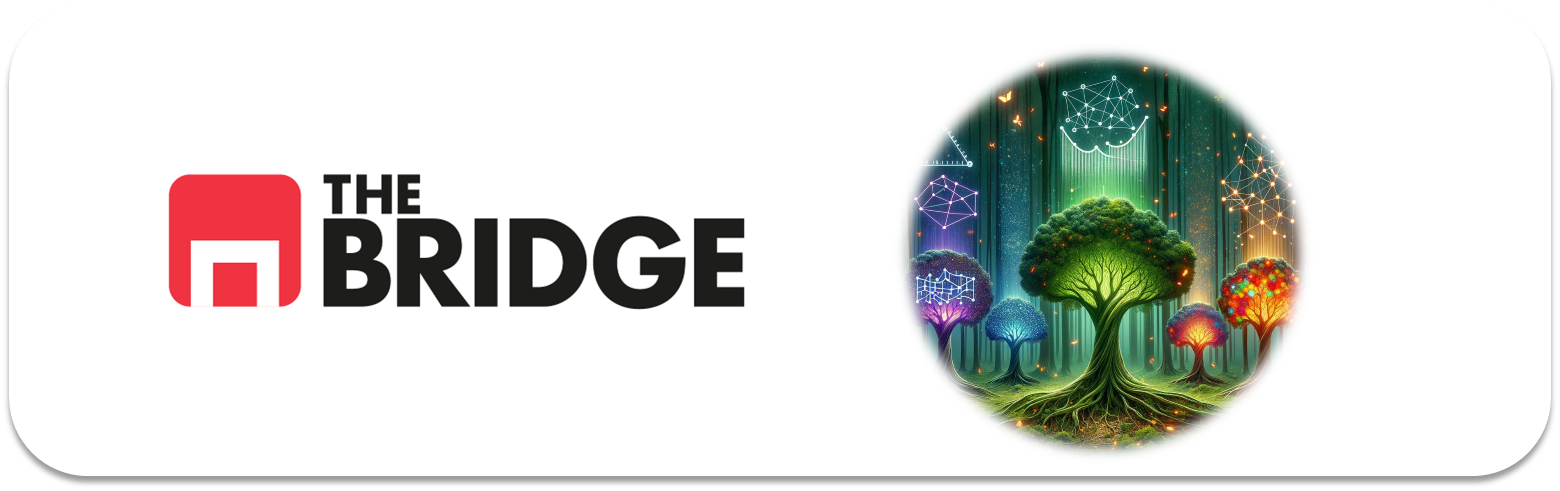

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.options.mode.copy_on_write = True

C:\Users\User\AppData\Local\Temp\ipykernel_15244\1106065509.py:16: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

In [3]:
df_diab = pd.read_csv(url, header = None, names = names)
df = df_diab.copy()

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.head(15)

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.nunique()

preg      17
plas     136
pres      47
skin      51
test     186
mass     248
pedi     517
age       52
class      2
dtype: int64

#### MiniEDA

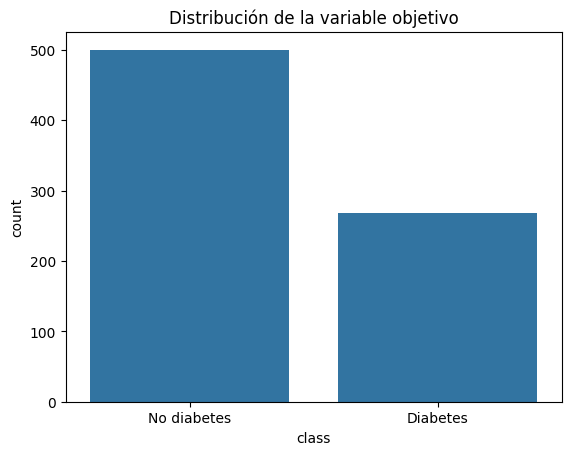

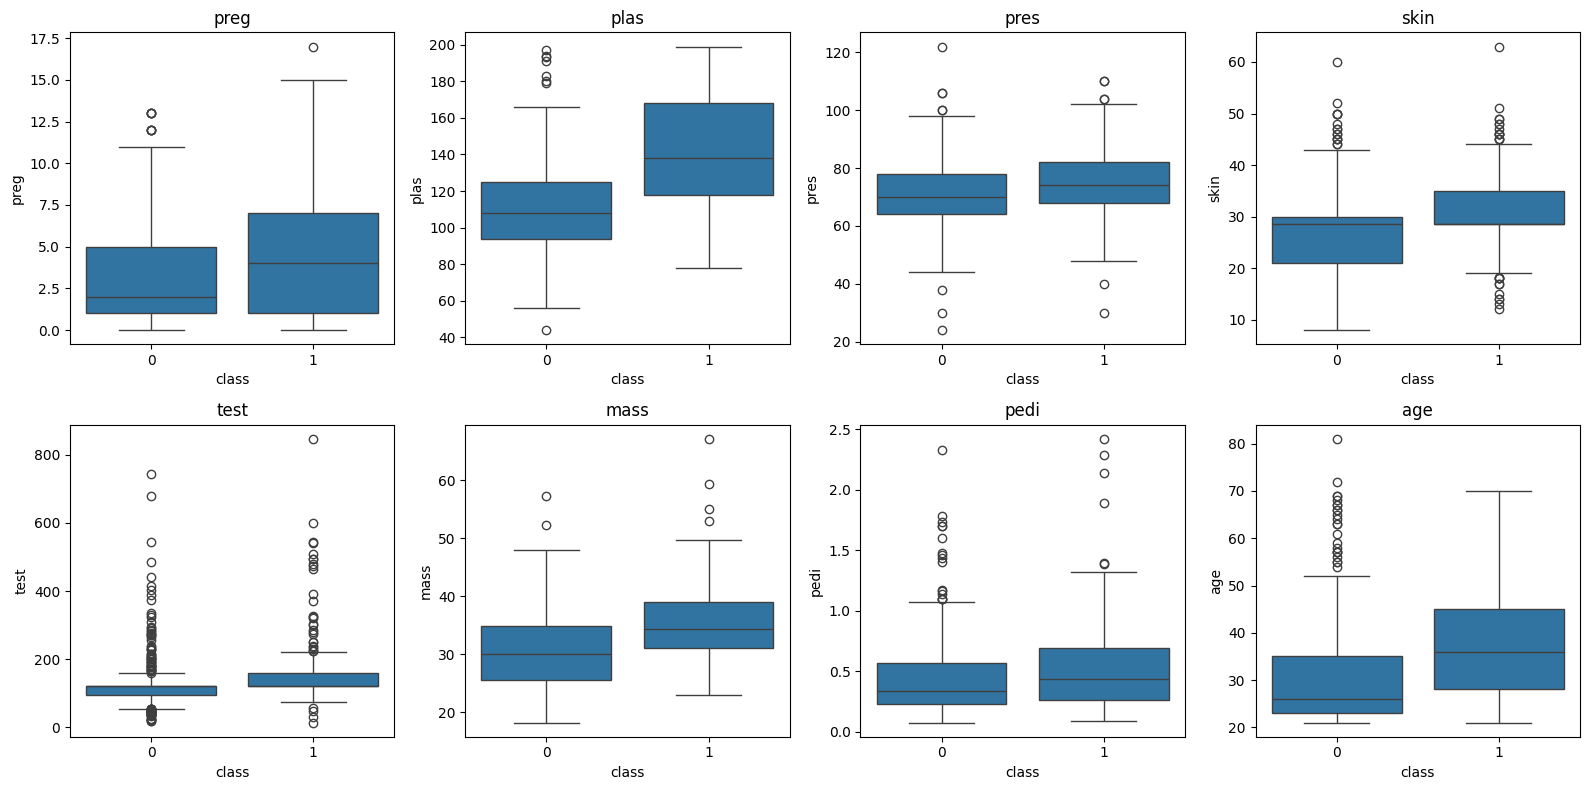

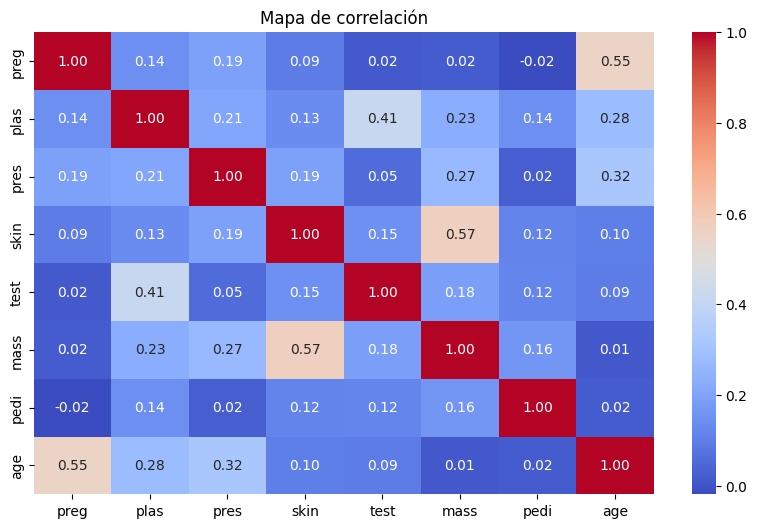

In [19]:
# 1. Distribución del target
sns.countplot(x='class', data=df)
plt.title("Distribución de la variable objetivo")
plt.xticks([0,1], ['No diabetes', 'Diabetes'])
plt.show()

# 2. Boxplots de cada variable por clase
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features_num):
    sns.boxplot(x='class', y=col, data=train_set, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 3. Correlación entre variables
plt.figure(figsize=(10, 6))
sns.heatmap(train_set[features_num].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()

In [8]:
# ¿Cuántos 0s hay en columnas donde biológicamente no pueden ser 0?
cols_check = ["plas", "pres", "skin", "test", "mass"]
print("Ceros por columna:")
print((df[cols_check] == 0).sum())
print(f"\nTotal filas afectadas: {(df[cols_check] == 0).any(axis=1).sum()} de {len(df)}")

Ceros por columna:
plas      5
pres     35
skin    227
test    374
mass     11
dtype: int64

Total filas afectadas: 376 de 768


##### Apuntar al target y crear el features

In [9]:
target = "class"

In [10]:
features_num = [c for c in df.columns if c != target]

#### Split

In [11]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

#### Imputación de ceros

In [12]:
con_nulos = ["plas", "pres", "skin", "test", "mass"]

train_set[con_nulos] = train_set[con_nulos].replace(0, np.nan)
test_set[con_nulos]  = test_set[con_nulos].replace(0, np.nan)

imp = SimpleImputer(strategy="median")
train_set[con_nulos] = imp.fit_transform(train_set[con_nulos])
test_set[con_nulos]  = imp.transform(test_set[con_nulos])

x_train = train_set[features_num]
y_train = train_set[target]
x_test  = test_set[features_num]
y_test  = test_set[target]

#### Baseline

Como está desbalanceado el df (65-35), utilizamos balanced_accuracy en lugar de accuracy

In [13]:
rf_clf  = RandomForestClassifier(max_depth=5, random_state=42)
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lgb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose=-1, n_jobs=-1)

for nombre, modelo in zip(["RandomForest", "XGBoost", "LightGBM"], [rf_clf, xgb_clf, lgb_clf]):
    score = np.mean(cross_val_score(modelo, x_train, y_train, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {score:.4f}")

RandomForest: 0.7183
XGBoost: 0.7171
LightGBM: 0.7258


#### Aplicación del Random Forest

In [14]:
rf_clf.fit(x_train, y_train)

pd.DataFrame({
    "feature": rf_clf.feature_names_in_,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

,feature,importance
1,plas,0.338001
5,mass,0.175836
7,age,0.155123
4,test,0.105071
6,pedi,0.074779
0,preg,0.055495
3,skin,0.049847
2,pres,0.045848


#### GridSearch

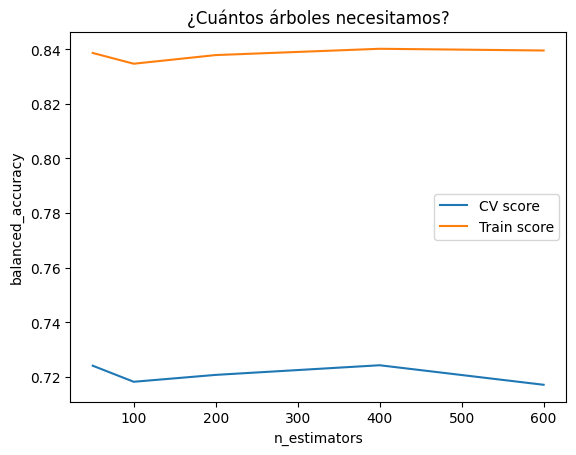

In [24]:
### EXTRA: Curva de validación

from sklearn.model_selection import validation_curve

train_scores, val_scores = validation_curve(
    RandomForestClassifier(max_depth=5, random_state=42),  # he añadido el max_depth para no overfittear,
    x_train, y_train,
    param_name="n_estimators",
    param_range=[50, 100, 200, 400, 600],
    cv=5, scoring="balanced_accuracy", n_jobs=-1
)

plt.plot([50,100,200,400,600], val_scores.mean(axis=1), label="CV score")
plt.plot([50,100,200,400,600], train_scores.mean(axis=1), label="Train score")
plt.xlabel("n_estimators")
plt.ylabel("balanced_accuracy")
plt.title("¿Cuántos árboles necesitamos?")
plt.legend()
plt.show()

In [15]:
# Ratio para balancear clases en xGBoost
ratio = len(train_set[train_set[target]==0]) / len(train_set[train_set[target]==1])

# xGBoost
xgb_grid = GridSearchCV(
    XGBClassifier(),
    param_grid={
        "n_estimators": [100, 200, 400],
        "eta": [0.1, 0.3, 0.6],
        "max_depth": [1, 6, 10],
        "min_child_weight": [1, 10, 100],
        "scale_pos_weight": [ratio, 1],
        "colsample_bytree": [0.5, 1]
    },
    cv=5, scoring="balanced_accuracy", n_jobs=-1
)
xgb_grid.fit(x_train, y_train)
print("xGBoost best score:", xgb_grid.best_score_)

# RandomForest
rf_grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid={
        "n_estimators": [100, 200, 400],
        "max_depth": [1, 5, 10, None],
        "min_samples_leaf": [1, 10, 20, 100],
        "class_weight": ["balanced", None],
        "max_features": ["sqrt", "log2", None]
    },
    cv=5, scoring="balanced_accuracy", n_jobs=-1
)
rf_grid.fit(x_train, y_train)
print("RandomForest best score:", rf_grid.best_score_)

# LightGBM
lgb_grid = GridSearchCV(
    LGBMClassifier(verbosity=-100),
    param_grid={
        "n_estimators": [100, 200, 400],
        "learning_rate": [0.1, 0.3, 0.6],
        "max_depth": [1, 6, 10, None],
        "min_data_in_leaf": [1, 10, 100],
        "class_weight": ["balanced", None],
        "max_bin": [40, 80, 100]
    },
    cv=5, scoring="balanced_accuracy", n_jobs=-1
)
lgb_grid.fit(x_train, y_train)
print("LightGBM best score:", lgb_grid.best_score_)

xGBoost best score: 0.7820971248103031
RandomForest best score: 0.7759262335425126
LightGBM best score: 0.7795263217259342


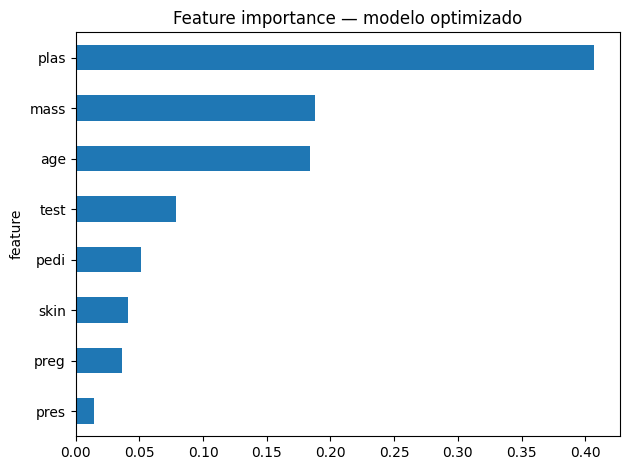

In [22]:
### EXTRA: Feature importance del modelo optimizado

best_rf = rf_grid.best_estimator_

pd.DataFrame({
    "feature": best_rf.feature_names_in_,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False).plot(
    kind="barh", x="feature", y="importance",
    title="Feature importance — modelo optimizado", legend=False
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Comparación del modelo y evaluación

In [16]:
# Comparación CV scores
for nombre, score in zip(["xGBoost", "RandomForest", "LightGBM"],
                         [xgb_grid.best_score_, rf_grid.best_score_, lgb_grid.best_score_]):
    print(f"{nombre}: {score:.4f}")

# Evaluación en test del mejor
print("\n--- RandomForest ---")
print(classification_report(y_test, rf_grid.best_estimator_.predict(x_test)))

print("\n--- xGBoost ---")
print(classification_report(y_test, xgb_grid.best_estimator_.predict(x_test)))

print("\n--- LightGBM ---")
print(classification_report(y_test, lgb_grid.best_estimator_.predict(x_test)))

xGBoost: 0.7821
RandomForest: 0.7759
LightGBM: 0.7795

--- RandomForest ---
              precision    recall  f1-score   support

           0       0.87      0.70      0.78        99
           1       0.60      0.82      0.69        55

    accuracy                           0.74       154
   macro avg       0.74      0.76      0.73       154
weighted avg       0.78      0.74      0.75       154


--- xGBoost ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76        99
           1       0.58      0.78      0.67        55

    accuracy                           0.72       154
   macro avg       0.72      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154


--- LightGBM ---
              precision    recall  f1-score   support

           0       0.84      0.70      0.76        99
           1       0.58      0.76      0.66        55

    accuracy                           0.72       154
   macro avg     

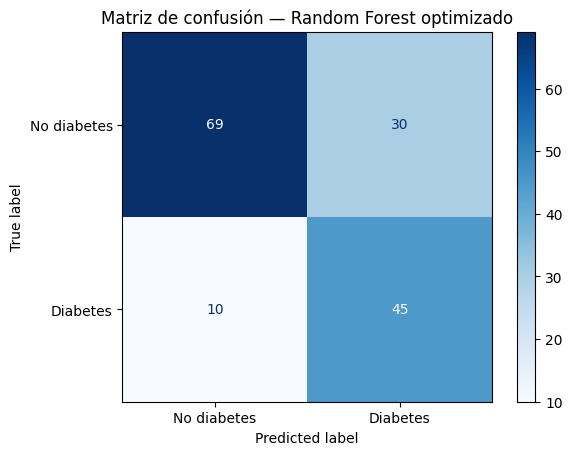

In [21]:
### EXTRA: Matriz de confusión del modelo final

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_grid.best_estimator_, x_test, y_test,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues"
)
plt.title("Matriz de confusión — Random Forest optimizado")
plt.show()